In [103]:
import math
import numpy as np
import trajan as ta
import xarray as xr
import parcels
import warnings

from parcels import StatusCode

from operator import attrgetter
from datetime import timedelta
from glob import glob

import matplotlib.pyplot as plt
from IPython.display import HTML
from matplotlib.animation import FuncAnimation

#from parcels import FileWarning

# Add a filter for the xarray decoding warning
#warnings.simplefilter("ignore", FileWarning)

folder = "/srv/seolab/srai/tropicalPacifiTemperatureBudget/WPWP_GLORYS_data/"
ufiles = sorted(glob(f"{folder}/GLORYS12v1_dailyAvg_withVerticalVelocities_2018-??-??.nc"))

fieldData = xr.open_mfdataset(ufiles)
sst = fieldData.thetao.isel(depth=0)

In [64]:
def combine_parcels_zarr(file_pattern):
    """
    Combines multiple parcels-output zarr files into a single xarray Dataset.
    Maintains original structure first, then creates a 1D 'time' coordinate 
    averaged across trajectories.
    """
    
    # 1. Get sorted list of files
    zarr_files = sorted(glob(file_pattern))
    if not zarr_files:
        raise ValueError(f"No Zarr files found matching pattern: {file_pattern}")

    # 2. Open individual datasets (as dask arrays for efficiency)
    # This step is standard opening. We don't modify structure yet.
    datasets = [xr.open_dataset(path, engine="zarr", chunks='auto') for path in zarr_files]
            
    # 3. Combine datasets using combine_nested along the 'trajectory' dimension
    # This stacks them into one large (trajectory, obs) dataset
    ds_combined = xr.combine_nested(datasets, concat_dim="trajectory")

    # 4. Handle NaT values and create a single 1D time coordinate
    
    # Apply mask to ensure NaT times lead to NaN data values
    valid_time_mask = ds_combined['time'].notnull()
    ds_combined = ds_combined.where(valid_time_mask, drop=False)
    
    # Since all trajectories share the exact same timestamps, 
    # we can average the 2D time array to get a 1D time array along 'obs'.
    # This 1D array has dimensions (obs).
    time_1d = ds_combined['time'].mean(dim='trajectory')

    # Drop the original 2D 'time' variable. We only need the 1D coordinate
    ds_combined = ds_combined.drop_vars('time')

    ds['time'] = time_1d

    # Assign this 1D time array as a *coordinate* called 'time' along the 'obs' dimension
    ds_combined = ds_combined.assign_coords(time=ds.time)

    # Swap coordinates
    ds_combined = ds_combined.swap_dims({"obs": "time"})

    # Drop the original 'obs' variable. We only need the 1D coordinate
    ds_combined = ds_combined.drop_vars('obs')
    
    


    return ds_combined

In [65]:
ds_timedim = combine_parcels_zarr("test.zarr/*.zarr")

/tmp/ipykernel_2985325/1303071380.py:19: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'obs' ('obs',) The recommendation is to set join explicitly for this case.
  ds_combined = xr.combine_nested(datasets, concat_dim="trajectory")


In [92]:
ds = ds_timedim

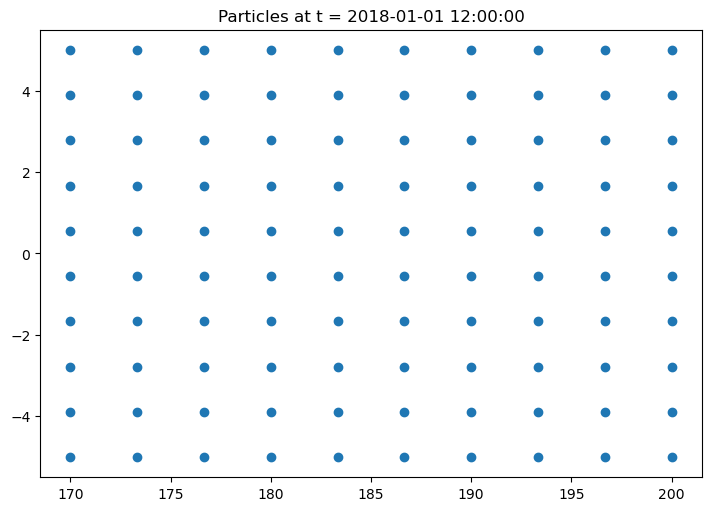

In [106]:
fig = plt.figure(figsize=(7, 5), constrained_layout=True)
ax = fig.add_subplot()

# show only every fifth output (for speed in creating the animation)
timerange = ds.time.to_numpy()

sc = ax.scatter(ds["lon"].isel(time=0).to_numpy(), ds["lat"].isel(time=0).to_numpy())

t = str(timerange[0])[0:19].replace('T',' ')
title = ax.set_title(f"Particles at t = {t}")


def animate(i):
    t = str(timerange[i])[0:19].replace('T',' ')
    title.set_text(f"Particles at t = {t}")

    sc.set_offsets(np.c_[ds["lon"].isel(time=i).to_numpy(), ds["lat"].isel(time=i).to_numpy()])


anim = FuncAnimation(fig, animate, frames=len(timerange), interval=100)
anim.save('box.mp4', writer='ffmpeg', fps=30)

In [107]:
HTML(anim.to_jshtml())

KeyboardInterrupt: 